# Разработка A/B-тестирования и анализ результатов

###  Цели и задачи проекта
Целью проекта является проврка нового алгоритма рекомендаций, который, по мнению команды разработчиков рекомендательных систем, будет показывать более интересный контент для каждого пользователя.

Задачи: рассчитать параметры A/B-теста, который позволит проверить гипотезу об улучшении рекомендаций, и проанализировать его результаты.

## Описание данных

Таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. 
- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. 

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. 

###  Работа с историческими данными (EDA)

####  Загрузка исторических данных


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
sessions_history = pd.read_csv()

Выведим на экран первые пять строк полученного датафрейма.

In [3]:
display(sessions_history.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведим на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. 


Рассчитаем количество уникальных сессий для каждого уникального пользователя:

In [4]:
session_count = sessions_history.groupby('user_id')['session_id'].nunique().sort_values(ascending=False)
display(session_count)

user_id
10E0DEFC1ABDBBE0    10
6A73CB5566BB494D    10
8A60431A825D035B     9
D11541BAC141FB94     9
5BCFE7C4DCC148E9     9
                    ..
1DF13BB1953B3497     1
628502A3CE7E0A3C     1
1DEEF40DEFBD0C65     1
AC08479B7472C628     1
8A0882B6715D9EE5     1
Name: session_id, Length: 134039, dtype: int64

Максимальное количество сессий составляет 10 и всего 2 пользователя с таким числом сессий. Выведим данные таблицы для одного из пользователей - 10E0DEFC1ABDBBE0:

In [5]:
display(sessions_history.loc[sessions_history['user_id']=='10E0DEFC1ABDBBE0'])

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Данные соотвествуют описанию, визуально столбцы заполнены корректно.

#### Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, проанализируем количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

Рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. 

In [6]:
total_user = sessions_history.groupby('session_date')['user_id'].nunique().reset_index()
reg_user = sessions_history.loc[sessions_history['registration_flag'] ==1].groupby('session_date')['user_id'].nunique().reset_index()

merge_df = pd.merge(total_user, reg_user, on='session_date', how='left') #объединим данные в одну таблицу
merge_df.columns = ['session_date', 'total_user', 'reg_user'] #переименуем столбцы для наглядности
merge_df['share_reg'] = round(merge_df['reg_user']/merge_df['total_user']*100,2)
display(merge_df)

,session_date,total_user,reg_user,share_reg
0,2025-08-11,3919,169,4.31
1,2025-08-12,6056,336,5.55
2,2025-08-13,8489,464,5.47
3,2025-08-14,10321,625,6.06
4,2025-08-15,14065,840,5.97
5,2025-08-16,12205,916,7.51
6,2025-08-17,11200,833,7.44
7,2025-08-18,10839,860,7.93
8,2025-08-19,12118,831,6.86
9,2025-08-20,13514,1008,7.46


Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. 

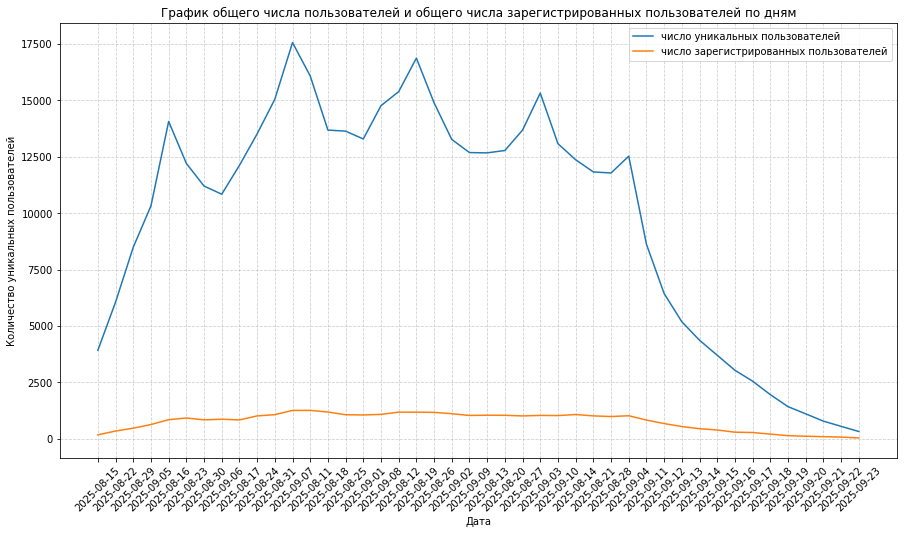

In [7]:
x = sessions_history['session_date'].unique()

plt.figure(figsize=(15, 8))
plt.plot(x, merge_df['total_user'], label ='число уникальных пользователей')
plt.plot(x, merge_df['reg_user'], label ='число зарегистрированных пользователей')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных пользователей")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.title('График общего числа пользователей и общего числа зарегистрированных пользователей по дням')
plt.show()

Построим линейный график доли зарегистрированных пользователей от всех пользователей по дням.

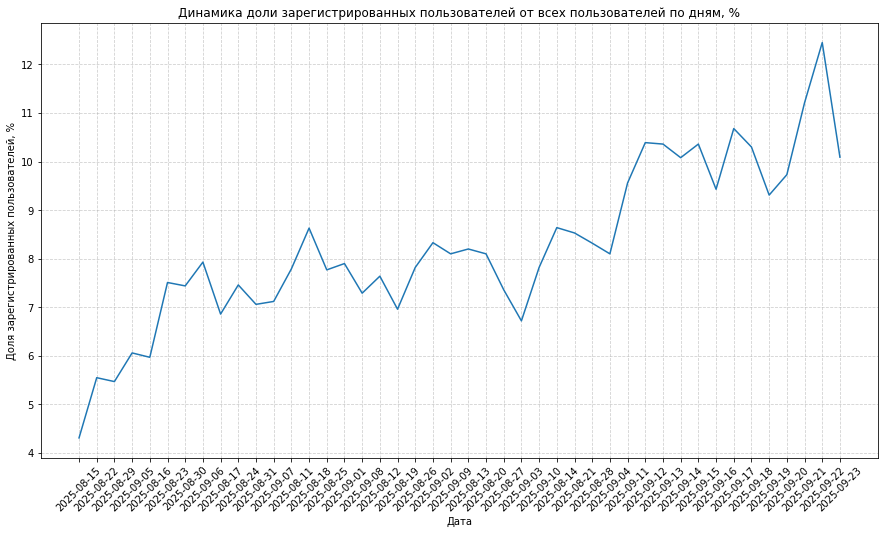

In [8]:
x = sessions_history['session_date'].unique()

plt.figure(figsize=(15, 8))
plt.plot(x, merge_df['share_reg'])

plt.xlabel("Дата")
plt.ylabel("Доля зарегистрированных пользователей, %")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Динамика доли зарегистрированных пользователей от всех пользователей по дням, %")
plt.show()

По данным видно, что с течением времени количество уникальных пользователей приложения не стабильно. А в период с 2025-09-10 наблюдается существенный спад до 317 пользователей в день (2025-09-23). 

Доля зарегистрированных пользователей растет, однако, при общем падении трафика, абсолютный показатель числа зарегистрированных пользователей также с течением времени падает.

#### Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц. 


Сформируем таблицу с количеством первых сессий для каждого значения количества просмотренных страниц.

In [9]:
page_counter = sessions_history.loc[sessions_history['session_number']==1].groupby('page_counter')['session_number'].count().reset_index()
display(page_counter)

,page_counter,session_number
0,1,8978
1,2,32494
2,3,50939
3,4,32739
4,5,8075
5,6,777
6,7,37


Построим для наглядности столбчатую диаграмму по сформированным данным.

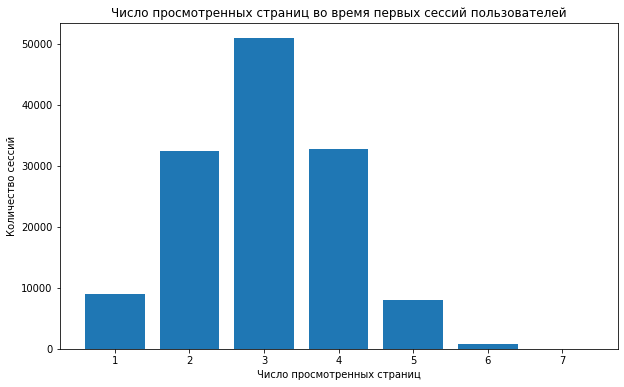

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(page_counter['page_counter'], page_counter['session_number'])

plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.title('Число просмотренных страниц во время первых сессий пользователей')
plt.show()

Больше всего во время первых сессий пользователи просматривают 3 страницы.

#### Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

Создадим новый столбец `good_session`.

In [11]:
sessions_history['good_session'] = 0
sessions_history.loc[sessions_history['page_counter']>=4, 'good_session'] = 1
display(sessions_history.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей по дням за весь период наблюдения.

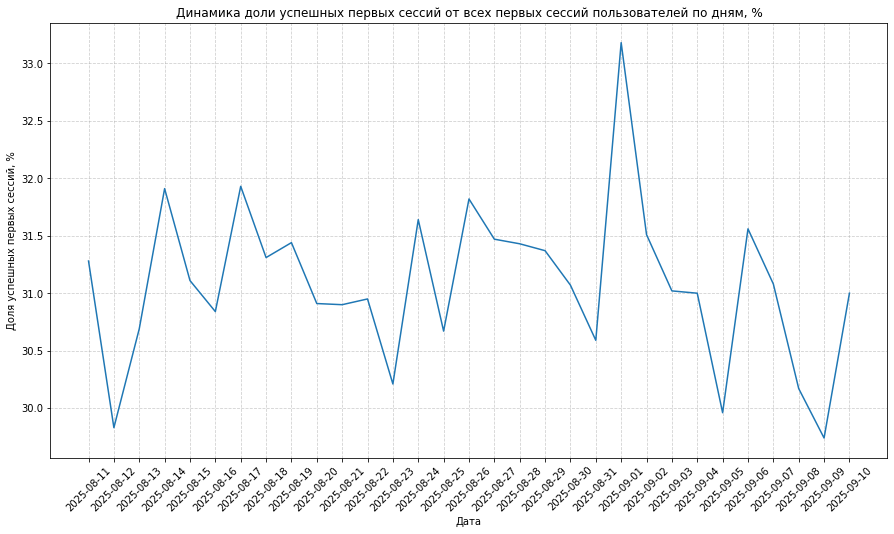

In [12]:
good_session = (sessions_history.loc[sessions_history['session_number']==1].groupby('session_date')['good_session'].mean()*100).round(2).reset_index()
x = good_session['session_date'].unique()

plt.figure(figsize=(15, 8))
plt.plot(x, good_session['good_session'])

plt.xlabel("Дата")
plt.ylabel("Доля успешных первых сессий, %")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Динамика доли успешных первых сессий от всех первых сессий пользователей по дням, %")
plt.show()

Доля успешных первых сессий от всех первых сессий пользователей варьируется в диапазоне от 29 до 33%.

### Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

####  Расчёт размера выборки
Установим в коде ниже следующие параметры для расчета:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. 

In [13]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаем параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода,  1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p*0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.


In [14]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean().round().astype(int)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


### Мониторинг А/В-теста

#### Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе убедимся, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.


In [15]:
sessions_test_part = pd.read_csv()

Выведем первые строки датафрейма для наглядности.

In [16]:
display(sessions_test_part.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [17]:
print(sessions_test_part['session_date'].unique())
print(sessions_test_part['test_group'].unique())

['2025-10-14']
['B' 'A']


Датафрейм соответствует описанию, в нем хранятся данные за один день наблюдений 2025-10-14 в разрезе групп А и В.
Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп.

In [18]:
A = sessions_test_part.loc[sessions_test_part['test_group']=='A']['user_id'].nunique()
B = sessions_test_part.loc[sessions_test_part['test_group']=='B']['user_id'].nunique()
print(f'Количество уникальных пользователей по группам А и В составляет {A, B} соответственно.')

Количество уникальных пользователей по группам А и В составляет (1477, 1466) соответственно.


Рассчитаем процентную разницу в количестве пользователей в группах A и B.

In [19]:
P = 100*((A-B)/A)
print(f'Процентная разница по группам А и В составляет {P:.2f}%.')

Процентная разница по группам А и В составляет 0.74%.


Разница между группами составляет менее процента, визуализируем для наглядности разницы круговую диаграмму.

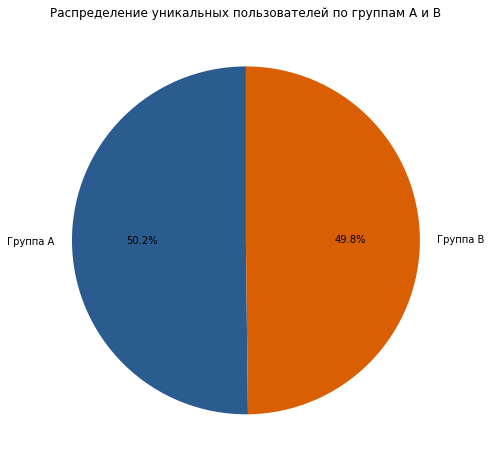

In [20]:
plt.figure(figsize=(15, 8))
custom_colors = ['#2b5c8f', '#d95f02']
plt.pie([A, B], labels=['Группа A', 'Группа B'], autopct='%1.1f%%', startangle=90, colors=custom_colors)

plt.title("Распределение уникальных пользователей по группам A и B")
plt.show()

Наглядно видно, что распределение пользователей по количеству корректно.

#### Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.


In [21]:
A_users = sessions_test_part.loc[sessions_test_part['test_group']=='A']['user_id'].unique()
B_users = sessions_test_part.loc[sessions_test_part['test_group']=='B']['user_id'].unique()
A_B_users = list(set(A_users) & set(B_users))
print("Пользователи в обеих группах:", A_B_users)

Пользователи в обеих группах: []


Проверка пользователей на пересечение в группах прошла успешно - таких пользователей нет.

#### Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.


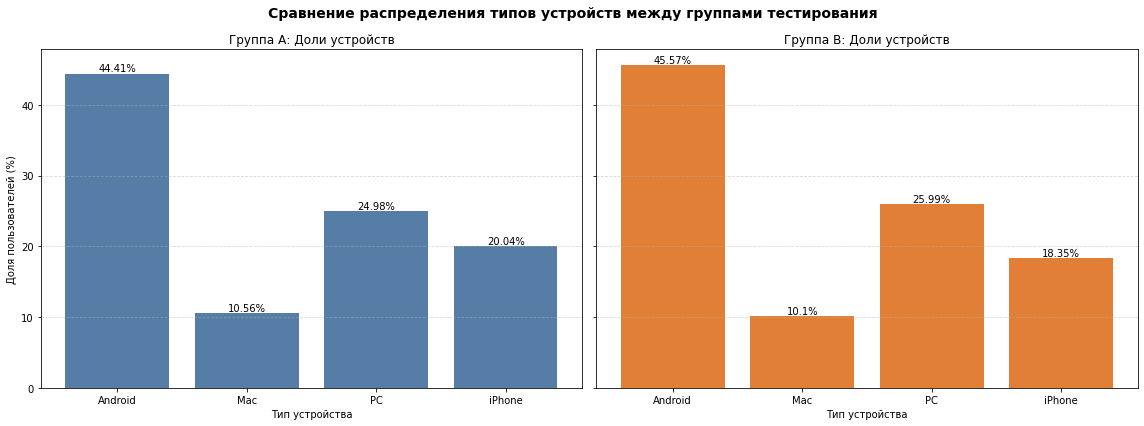

In [22]:
# Считаем долю устройств для гррупп тестирования
A_device = sessions_test_part.loc[sessions_test_part['test_group']=='A'].groupby('device')['user_id'].nunique().reset_index()
A_device['share'] = (A_device['user_id']/(A_device['user_id'].sum())*100).round(2)
B_device = sessions_test_part.loc[sessions_test_part['test_group']=='B'].groupby('device')['user_id'].nunique().reset_index()
B_device['share'] = (B_device['user_id']/(B_device['user_id'].sum())*100).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Строим график для группы А
ax1.bar(A_device['device'], A_device['share'], color='#2b5c8f', alpha=0.8)
ax1.set_title('Группа А: Доли устройств', fontsize=12)
ax1.set_xlabel('Тип устройства')
ax1.set_ylabel('Доля пользователей (%)')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Добавим текстовые подписи процентов над столбцами для группы А
for bar in ax1.patches:
    ax1.annotate(f"{bar.get_height()}%", 
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                 ha='center', va='bottom', fontsize=10)

# Строим график для группы B
ax2.bar(B_device['device'], B_device['share'], color='#d95f02', alpha=0.8)
ax2.set_title('Группа B: Доли устройств', fontsize=12)
ax2.set_xlabel('Тип устройства')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Добавим текстовые подписи процентов над столбцами для группы B
for bar in ax2.patches:
    ax2.annotate(f"{bar.get_height()}%", 
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                 ha='center', va='bottom', fontsize=10)

fig.suptitle('Сравнение распределения типов устройств между группами тестирования', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Распределение по типам устройств между группами без существенных отклонений и составляет примерно 1-1,5% в разреззе устройств.

#### Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.


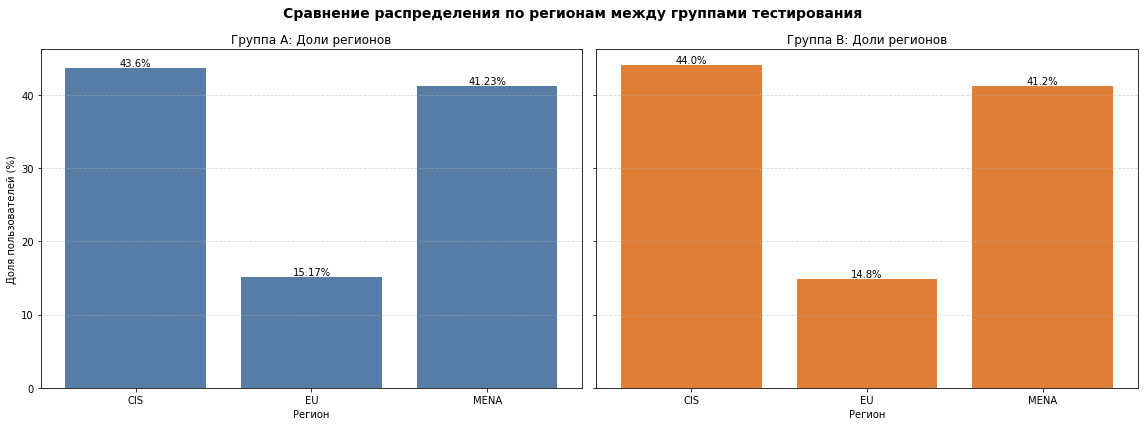

In [23]:
# Считаем долю распределения по регионам для гррупп тестирования
A_region = sessions_test_part.loc[sessions_test_part['test_group']=='A'].groupby('region')['user_id'].nunique().reset_index()
A_region['share'] = (A_region['user_id']/(A_region['user_id'].sum())*100).round(2)
B_region = sessions_test_part.loc[sessions_test_part['test_group']=='B'].groupby('region')['user_id'].nunique().reset_index()
B_region['share'] = (B_region['user_id']/(B_region['user_id'].sum())*100).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Строим график для группы А
ax1.bar(A_region['region'], A_region['share'], color='#2b5c8f', alpha=0.8)
ax1.set_title('Группа А: Доли регионов', fontsize=12)
ax1.set_xlabel('Регион')
ax1.set_ylabel('Доля пользователей (%)')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Добавим текстовые подписи процентов над столбцами для группы А
for bar in ax1.patches:
    ax1.annotate(f"{bar.get_height()}%", 
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                 ha='center', va='bottom', fontsize=10)

# Строим график для группы B
ax2.bar(B_region['region'], B_region['share'], color='#d95f02', alpha=0.8)
ax2.set_title('Группа B: Доли регионов', fontsize=12)
ax2.set_xlabel('Регион')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Добавим текстовые подписи процентов над столбцами для группы B
for bar in ax2.patches:
    ax2.annotate(f"{bar.get_height()}%", 
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                 ha='center', va='bottom', fontsize=10)

fig.suptitle('Сравнение распределения по регионам между группами тестирования', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Распределение по регионам между группами также без существенных отклонений и составляет менее 1% в разреззе регионов.

#### Выводы после проверки A/B-теста


- *Проверка хода тестирования показала, что тест производится по заданным критериям и нарушений, влияющих на итоговые показатели нет. Рапределение количества пользователей по группам А и В составляет 50.2%/49.8% соответственно.*
- *Выборки независимы, пользователей попавших в обе группы нет.*
- *Также пользователи равномерно распределены по типам устройств и регионам (отклонения составляют 0-1.5% в разрезе исследуемых категорий).*

### Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### Получение результатов теста и подсчёт основной метрики


In [24]:
sessions_test = pd.read_csv()

Поссичтаем фактическую выборку и кличество дней проведения эксперимента.

In [25]:
selection = sessions_test.groupby('session_date')['user_id'].nunique().sum()
days = sessions_test['session_date'].nunique()
print(f'Выборка составила {selection} пользователей в сумме дней, количество дней эксперимента составлило {days}.')

Выборка составила 99171 пользователей в сумме дней, количество дней эксперимента составлило 20.


Создадим дополнительный столбец: `good_session`.

In [26]:
sessions_test['good_session'] = 0
sessions_test.loc[sessions_test['page_counter']>=4,'good_session'] = 1
display(sessions_test.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


*В качестве целевой метрики гипотезы используем `долю успешных первых сессий`. То есть по новому алгоритму должно увеличится количество первых сессий с просмотром страниц от 4 и более.*

- Нулевая гипотеза (Н0) - доля успешных первых сессий между группами А и В не изменилась.
- Альтернативная гипотеза (Н1) - доля успешных первых сессий в группе В выше чем в группе А.

Определим прокси- метрику:
- `Среднее количество сессий на пользователя.`

Увеличение этой метрики может свидетельствовать о том, что рекомендательный контент для каждого пользователя стал более интересным.

Определим барьерную метрику:
- `Количество числа регистраций за каждый день`

Снижение этой метрики может свидетельствовать о том, что рекомендательного контента стало более чем достаточно и интереса в большее погружение в приложение нет.

#### Сравнение доли успешных первых сессий


In [27]:
A_test_mean = sessions_test.loc[(sessions_test['test_group']=='A')&(sessions_test['session_number']==1)]['good_session'].mean()
B_test_mean = sessions_test.loc[(sessions_test['test_group']=='B')&(sessions_test['session_number']==1)]['good_session'].mean()
diff = 100*((B_test_mean-A_test_mean)/A_test_mean)
print(f'Доля успешных первых сессий в группе А: {A_test_mean:.2f}')
print(f'Доля успешных первых сессий в группе B: {B_test_mean:.2f}')
print(f'Относительное изменение показателя группе B: {diff:.2f}%')

Доля успешных первых сессий в группе А: 0.32
Доля успешных первых сессий в группе B: 0.31
Относительное изменение показателя группе B: -0.33%


####  Насколько статистически значимо изменение ключевой метрики



Напишим вспомогательную функцию print_stattest_results(p_value, alpha), которая будет интерпретировать результаты статистических тестов на основе p-value и заданного уровня значимости (α-уровня). Функция должна решать, следует ли принять альтернативную гипотезу или сохранить нулевую гипотезу.

У функции два параметра:

- p_value (тип float) — значение p-value, полученное в результате выполнения статистического теста.
- alpha (тип float, alpha = 0.05) — уровень значимости статистического теста, который используется как порог для принятия решения об отклонении нулевой гипотезы.

In [28]:
def print_stattest_results(p_value:float, alpha:float = 0.05):
    if p_value < alpha:
        print(f'Полученное значение {p_value=} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение {p_value=} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')
print('Проверка функции:')
print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Проверка функции:
Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


Рассчитаем значение p_value для выбранной гипотезы, используя функции модуля scipy.stats и односторонний t-тест.

In [29]:
A_test = sessions_test.loc[(sessions_test['test_group']=='A')&(sessions_test['session_number']==1)]['good_session']
B_test = sessions_test.loc[(sessions_test['test_group']=='B')&(sessions_test['session_number']==1)]['good_session']

results = st.ttest_ind (A_test, B_test, alternative='less') 
p_value = results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.578349228097416 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


#### Вывод по результатам A/B-эксперимента


При подготовке эксперимента были рассчитаны размер выборки и количество дней эксперимента. Расчетно минимальный размер выборки на группу составил 41040 (общая выборка 82080), количество дней эсперимента по историческим данным в среднем трафике в 9907 пользователей в день должен был составить 9 дней.

Фактически общая выборка составила 99171 пользователей в сумме всех дней эксперимента, количество дней эксперимента составлило 20.

Разница в сроке проведения эксперимента с расчетным обусловлена меньшим фактическим трафиком пользователей.

Среднее значение ключевой метрики `Доля успешных первых сессий` после внедрения нового алгоритма снизилось на -0.33%.
Так в группе А значение метрики показало результат - 0.32, в группе B - 0.31.

Полученное значение p_value=0.578349228097416 больше критического уровня alpha=0.05. 

Таким образом, опровергнуть гипотезу о том, что доля успешных первых сессий между группами А и В не изменилась нельзя.

По результатам проведенного тестирования можно сделать вывод, что нововведение в приложение нецелесообразно.